In [1]:
from google.colab import files

uploaded = files.upload()

Saving dataset_A_PERFECT.csv to dataset_A_PERFECT.csv


In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset_B_SYNONYM.csv to dataset_B_SYNONYM.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving dataset_C_LOGIC_ERROR.csv to dataset_C_LOGIC_ERROR.csv



 METHOD 2 — ADVANCED RULE-BASED RESULTS
Accuracy A: 90.00%
Accuracy B: 20.00%
Accuracy C: 5.00%
----------------------------------------
False Alarm A: 10.00%
False Alarm B: 80.00%
Logic Error Recall C: 5.00%
----------------------------------------
Saved: predictions_A_advanced.csv
Saved: predictions_B_advanced.csv
Saved: predictions_C_advanced.csv


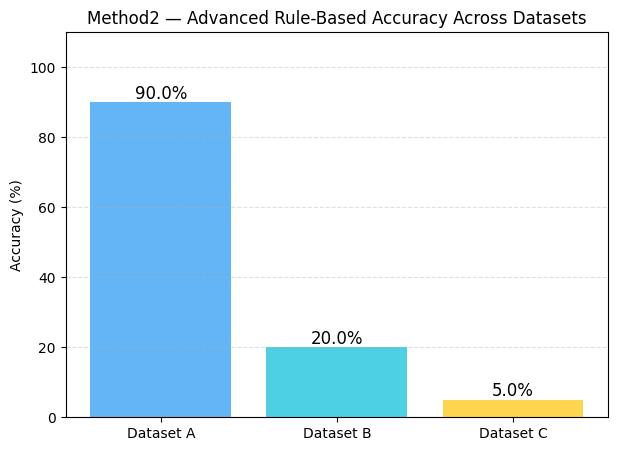

In [4]:
# Method2 — Advanced Rule Based

import re
import string
import pandas as pd
from difflib import SequenceMatcher
import matplotlib.pyplot as plt

# adding synonyms dictionary to better the matching ( note :- we can also use other advanced methods) (we can check it later at last)

SYNONYMS = {
    "user": ["applicant", "customer", "client"],
    "applicant": ["user", "candidate"],
    "student": ["learner", "pupil"],
    "teacher": ["instructor"],
    "course": ["class"],
    "form": ["document", "application"],
    "application": ["form"]
}

# TEXT CLEANING

def clean_text(text):
    if not isinstance(text, str):
        return ""
    return text.lower().translate(str.maketrans("", "", string.punctuation)).strip()


# Requirement extraxtion

def extract_requirement_terms(req):
    req = clean_text(req)
    words = [w for w in req.split() if len(w) > 3]

    expanded = set(words)
    for w in words:
        if w in SYNONYMS:
            expanded.update(SYNONYMS[w])

    return expanded

# ------------------------------------------------------------
#  Extraction from term UML  (only entities amnd attributes)
# ------------------------------------------------------------
def extract_uml_terms(uml):
    txt = clean_text(uml)

    # Entities
    entities = re.findall(r'entity\s+(\w+)', txt)

    # Attributes
    matches = re.findall(r'\{\s*([^}]*)\}', txt)
    attr_terms = []
    for block in matches:
        parts = block.split()
        for p in parts:
            p = p.strip()
            if len(p) > 3:
                attr_terms.append(p)

    return set([t.lower() for t in (entities + attr_terms)])


# Similarity

def sim(a, b):
    return SequenceMatcher(None, a, b).ratio()

#Predictor

TERM_THRESHOLD = 0.55
MATCH_RATIO_THRESHOLD = 0.45

def advanced_predict(req, uml):
    req_terms = extract_requirement_terms(req)
    uml_terms = extract_uml_terms(uml)

    if len(req_terms) == 0 or len(uml_terms) == 0:
        return "MISMATCH", 0.0

    scores = []
    for r in req_terms:
        best = max(sim(r, u) for u in uml_terms)
        scores.append(best)

    weighted = sum(scores) / len(scores)

    label = "MATCH" if weighted >= MATCH_RATIO_THRESHOLD else "MISMATCH"
    return label, weighted


# Metrics

def evaluate_accuracy(path):
    df = pd.read_csv(path)
    correct = 0
    for req, uml, label in zip(df["Requirement"], df["PlantUML"], df["Label"]):
        pred, score = advanced_predict(req, uml)
        if pred == label:
            correct += 1
    return (correct / len(df)) * 100

def false_alarm_rate(path):
    df = pd.read_csv(path)
    false_alarms = 0
    for req, uml, label in zip(df["Requirement"], df["PlantUML"], df["Label"]):
        pred, score = advanced_predict(req, uml)
        if pred == "MISMATCH" and label == "MATCH":
            false_alarms += 1
    return (false_alarms / len(df)) * 100

def logic_error_recall(path):
    df = pd.read_csv(path)
    correct_detect = 0
    for req, uml, label in zip(df["Requirement"], df["PlantUML"], df["Label"]):
        pred, score = advanced_predict(req, uml)
        if pred == "MISMATCH" and label == "MISMATCH":
            correct_detect += 1
    return (correct_detect / len(df)) * 100

#saving predictions

def generate_prediction_file(infile, outfile):
    df = pd.read_csv(infile)
    preds = []
    confs = []

    for req, uml in zip(df["Requirement"], df["PlantUML"]):
        pred, score = advanced_predict(req, uml)
        preds.append(pred)
        confs.append(round(score, 3))

    df["Prediction"] = preds
    df["Confidence"] = confs
    df.to_csv(outfile, index=False)
    print("Saved:", outfile)

# Graph plot

def plot_accuracy(acc_A, acc_B, acc_C):
    labels = ["Dataset A", "Dataset B", "Dataset C"]
    values = [acc_A, acc_B, acc_C]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values, color=["#64B5F6", "#4DD0E1", "#FFD54F"])

    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{bar.get_height():.1f}%", ha='center', fontsize=12)

    plt.ylim(0, 110)
    plt.ylabel("Accuracy (%)")
    plt.title("Method2 — Advanced Rule-Based Accuracy Across Datasets")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.show()

#  ewxecution

A = "dataset_A_PERFECT.csv"
B = "dataset_B_SYNONYM.csv"
C = "dataset_C_LOGIC_ERROR.csv"

acc_A = evaluate_accuracy(A)
acc_B = evaluate_accuracy(B)
acc_C = evaluate_accuracy(C)

fa_A = false_alarm_rate(A)
fa_B = false_alarm_rate(B)
recall_C = logic_error_recall(C)

print("\n METHOD 2 — ADVANCED RULE-BASED RESULTS")
print(f"Accuracy A: {acc_A:.2f}%")
print(f"Accuracy B: {acc_B:.2f}%")
print(f"Accuracy C: {acc_C:.2f}%")
print("----------------------------------------")
print(f"False Alarm A: {fa_A:.2f}%")
print(f"False Alarm B: {fa_B:.2f}%")
print(f"Logic Error Recall C: {recall_C:.2f}%")
print("----------------------------------------")

# Save predictions

generate_prediction_file(A, "predictions_A_advanced.csv")
generate_prediction_file(B, "predictions_B_advanced.csv")
generate_prediction_file(C, "predictions_C_advanced.csv")

# Plot graph

plot_accuracy(acc_A, acc_B, acc_C)
